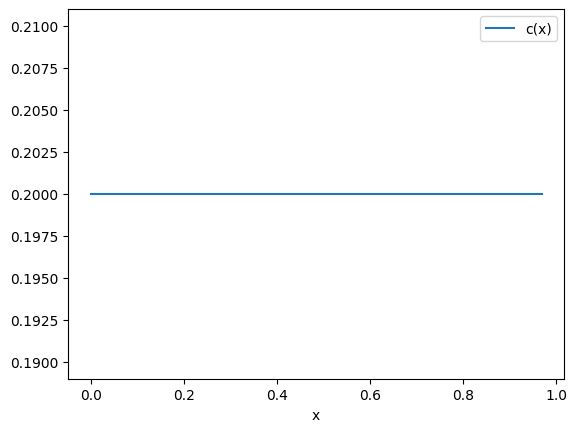

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.circuit.library import DiagonalGate, QFTGate, StatePreparation, UnitaryGate
from qiskit.quantum_info import Statevector
from scipy.linalg import expm

n_qubits = 5
N = 2**n_qubits
L = 1#2 * np.pi               
t = 1     
x = np.linspace(0, L, N, endpoint=False)
dx = L / N

# Parameters
c_val = 0.2
c = c_val * np.ones_like(x) 


plt.plot(x, c, label='c(x)')
plt.xlabel('x')
plt.legend()

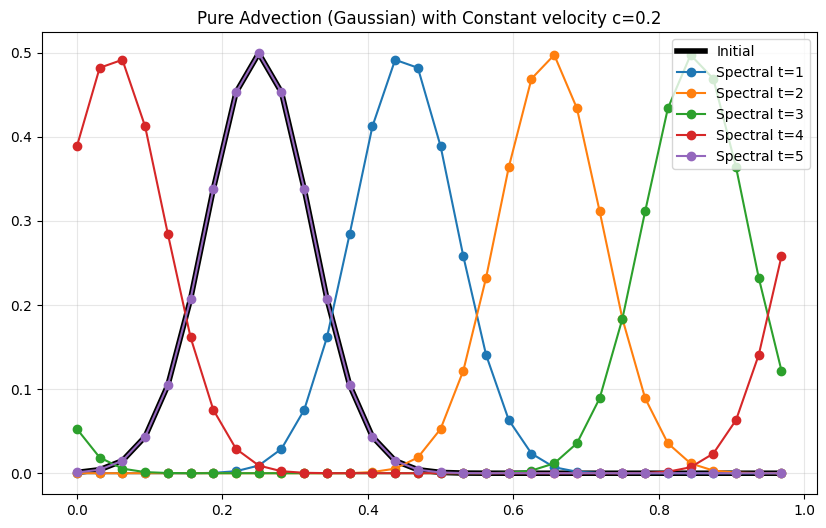

In [6]:
j_indices = np.arange(N)
k_indices = np.where(j_indices <= N/2, j_indices, j_indices - N)
P_1 = 1j * (2 * np.pi / L) * (k_indices)



initial_state = "Gaussian" #| "Box" or "Gaussian"
if initial_state == "Gaussian":
    sigma = L/20
    state = np.exp(-0.25*((x-dx*N/4)/sigma)**2)
elif initial_state == "Box":
    state = np.where((x > L/4) & (x < L/2), 1.0, 0.0)

state = state / np.linalg.norm(state)
plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k-', linewidth=4, label='Initial')

for t in [1, 2, 3, 4, 5]:
    reg_s = QuantumRegister(n_qubits, 'system')
    circuit = QuantumCircuit(reg_s)
    stateprep = StatePreparation(state)
    circuit.append(stateprep,reg_s)



    circuit.append(QFTGate(n_qubits), reg_s)
    circuit.append(DiagonalGate(np.exp(t*c*P_1)), reg_s)
    circuit.append(QFTGate(n_qubits).inverse(), reg_s)


    final_state = Statevector(circuit)
    full_data = np.array(final_state)

    system_state = full_data

    success_prob = np.linalg.norm(system_state)**2
    final = system_state / np.linalg.norm(system_state)

    plt.plot(x, np.real(final), 'o-', label=f'Spectral t={t}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Pure Advection (Gaussian) with Constant velocity c=0.2')
plt.show()

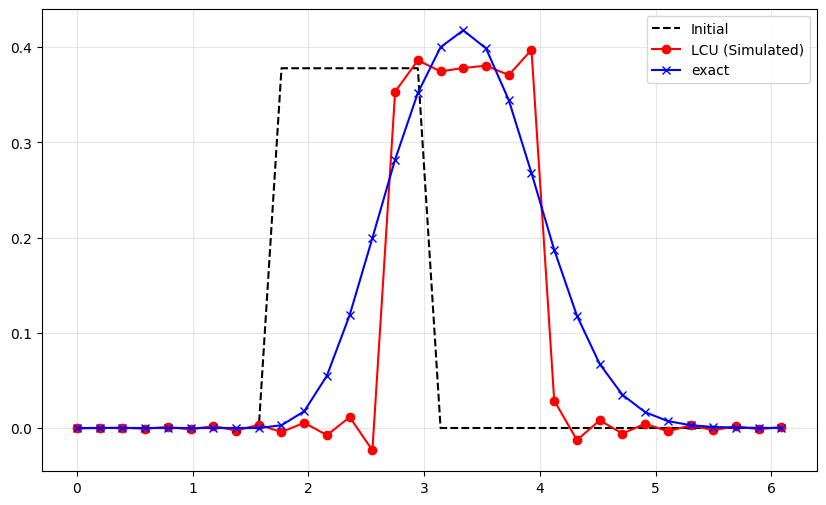

In [14]:

gamma_s = 1.0 / dx


c_left = np.roll(c, 1)    # index i contains c_{i-1}

val_lower = gamma_s * c_left


M = np.diag(val_lower[1:], k=-1) + np.diag(-gamma_s*c, k=0)
M[0, N-1] = val_lower[0]

u_final = expm(M * t) @ state




plt.figure(figsize=(10, 6))
plt.plot(x, state, 'k--', label='Initial')
plt.plot(x, np.real(final), 'ro-', label=f'LCU (Simulated)')
plt.plot(x, u_final/np.linalg.norm(u_final), 'bx-', label=f'exact')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()